In [24]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [ ]:
class State(TypedDict):
    """Represents a state in the conversation graph."""

    messages: Annotated[list, add_messages]


graph_builder = StateGraph(State)

In [26]:
graph_builder

In [39]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [28]:
from langchain_groq import ChatGroq

llm = ChatGroq(model="llama-3.1-8b-instant")

In [ ]:
## Node functionality
def chatbot(state: State):
    return {"messages": [llm.invoke(state["messages"])]}

In [ ]:
graph_builder = StateGraph(State)

# add nodes and edges to the graph
graph_builder.add_node("llmchatbot", chatbot)
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile the graph
graph = graph_builder.compile()

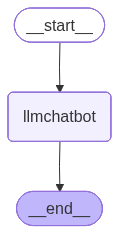

In [31]:
graph

In [ ]:
response = graph.invoke({"messages": "Hello, how are you?"})

In [33]:
response

{'messages': [HumanMessage(content='Hello, how are you?', additional_kwargs={}, response_metadata={}, id='da73e189-5232-4be0-9848-d24ee8ca899f'),
  AIMessage(content="Hello. I'm functioning properly. How can I assist you today?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 41, 'total_tokens': 56, 'completion_time': 0.030691611, 'completion_tokens_details': None, 'prompt_time': 0.00849839, 'prompt_tokens_details': None, 'queue_time': 0.281184197, 'total_time': 0.039190001}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_4387d3edbb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019eb2ab-942b-7292-8a17-e002f1095227-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 41, 'output_tokens': 15, 'total_tokens': 56})]}

In [34]:
response["messages"][-1].content

"Hello. I'm functioning properly. How can I assist you today?"

In [ ]:
for event in graph.stream({"messages": "Hello, how are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm functioning properly, thank you for asking. How can I assist you today?


## Langgrah with tools


In [ ]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("What is langgraph?")

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? - IBM',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. The following example can offer a clearer understanding of LangGraph: Think about these graph-based architectures as a powerful configurable map, a “Super-Map.” Users can envision the AI workflow as being “The Navigator” of this “Super-Map.” Finally, in this example, the user is “The Cartographer.” In this sense, the 

### Custom tool


In [ ]:
def multiply(a: int, b: int) -> int:
    """
    Multiplies a and b

    Args:
            a (int): The first number
            b (int): The second number
    Returns:
            int: The product of a and b
    """
    return a * b

In [50]:
tools=[tool, multiply]
tools

[TavilySearch(max_results=2, api_wrapper=TavilySearchAPIWrapper(tavily_api_key=SecretStr('**********'), api_base_url=None)),
 <function __main__.multiply(a: int, b: int) -> int>]

In [52]:
llm_with_tools=llm.bind_tools(tools)

ValueError: Arg Returns in docstring not found in function signature.